In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

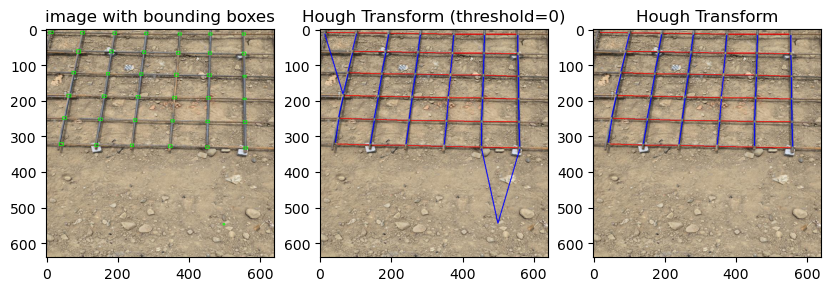

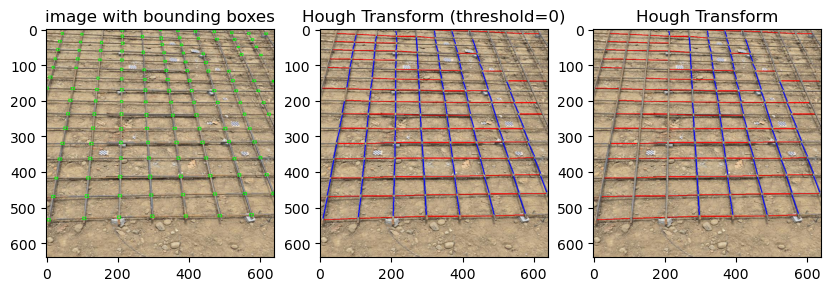

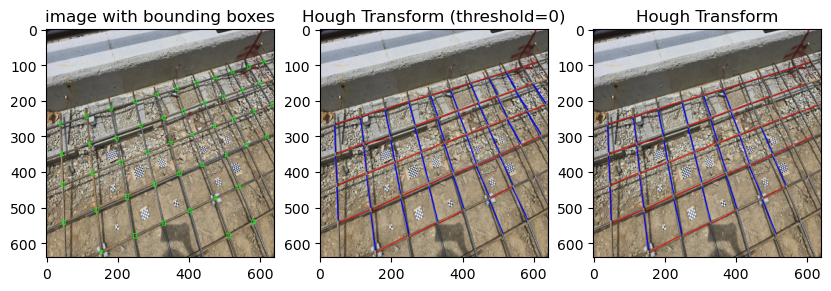

In [2]:
image_paths = [
    "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg",
    "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg",
    "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg",
]
model_path = "runs/detect/tune/weights/best.pt"


# Draw bounding boxes
def draw_bounding_boxes(image_path, model_path):
    image = Image.open(image_path)
    draw_boxes = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image, model_path)
    for box in bounding_boxes:
        draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=2)

    return image


# Draw lines
def draw_lines(image_path, model_path, threshold=10):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image_path, model_path, threshold=threshold)
    data = json.loads(json_data)
    for shape in data["shapes"]:
        points = shape["points"]
        color = "red" if shape["orientation"] == "horizontal" else "blue"
        draw_lines.line([tuple(points[0]), tuple(points[1])], fill=color, width=3)

    return image


def show_result(image_path, model_path):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("image with bounding boxes")
    plt.imshow(draw_bounding_boxes(image_path, model_path))
    plt.subplot(1, 3, 2)
    plt.title("Hough Transform (threshold=0)")
    # Still applying line pruning
    plt.imshow(draw_lines(image_path, model_path, threshold=0))
    plt.subplot(1, 3, 3)
    plt.title("Hough Transform")
    plt.imshow(draw_lines(image_path, model_path, threshold=10))
    plt.show()


for path in image_paths:
    show_result(path, model_path)
